# Support Vector Machine Model

In [1]:
from SVM_utils import *
import numpy as np
from utils import *

D, L = load("train_data.txt")
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L)
pi_target = 0.1
K = 1.0

In [2]:
Cs = np.logspace(-5, 0, 11)
best_scores = None
best_accuracy = -1
DCFs = []

for C in Cs:
    w_hat_star = train_linear_SVM(D_training, L_training, C, K)
    S = linear_SVM_scores(D_eval, w_hat_star, K)
    preds, accuracy = eval_SVM(S, L_eval)
    if(accuracy > best_accuracy): best_scores = S
    minDFC = compute_min_dcf(S, L_eval, pi_target, 1, 1)
    actDCF = compute_act_dcf(preds, L_eval, pi_target, 1, 1)
    DCFs.append((minDFC, actDCF))

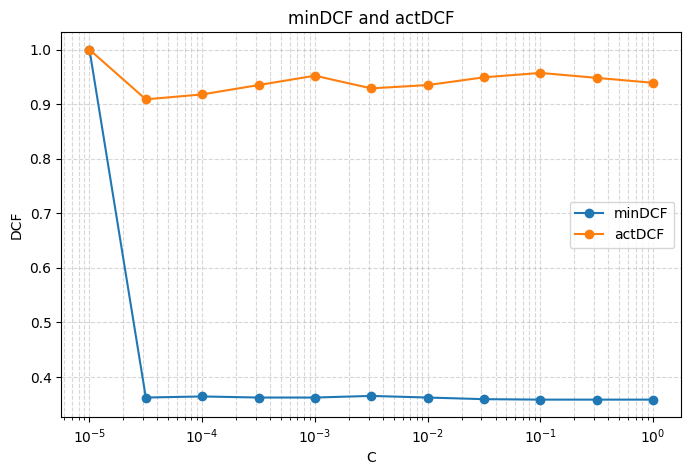

In [3]:
import matplotlib.pyplot as plt

minDCFs = [d[0] for d in DCFs]
actDCFs = [d[1] for d in DCFs]

plt.figure(figsize=(8, 5))
plt.plot(Cs, minDCFs, label='minDCF', marker='o')
plt.plot(Cs, actDCFs, label='actDCF', marker='o')
plt.xscale('log')  
plt.xlabel('C')
plt.ylabel('DCF')
plt.title('minDCF and actDCF')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In [4]:
def center_data(DTR, DVAL = None):
    mu = np.sum(DTR, axis=1) / DTR.shape[1]
    DTR_centered = DTR - vcol(mu)
    if DVAL is not None:
        DVAL_centered = DVAL - vcol(mu)
        return DTR_centered, DVAL_centered
    return DTR_centered, None

DTRC, DVALC = center_data(D_training, D_eval)

Cs = np.logspace(-5, 0, 11)
best_scores = None
best_accuracy = -1
DCFs = []

for C in Cs:
    w_hat_star = train_linear_SVM(DTRC, L_training, C, K)
    S = linear_SVM_scores(DVALC, w_hat_star, K)
    preds, accuracy = eval_SVM(S, L_eval)
    if(accuracy > best_accuracy): best_scores = S
    minDFC = compute_min_dcf(S, L_eval, pi_target, 1, 1)
    actDCF = compute_act_dcf(preds, L_eval, pi_target, 1, 1)
    DCFs.append((minDFC, actDCF))

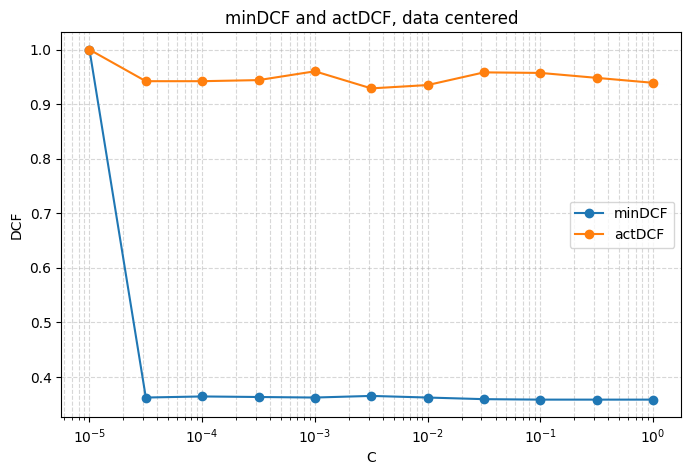

In [5]:
minDCFs = [d[0] for d in DCFs]
actDCFs = [d[1] for d in DCFs]

plt.figure(figsize=(8, 5))
plt.plot(Cs, minDCFs, label='minDCF', marker='o')
plt.plot(Cs, actDCFs, label='actDCF', marker='o')
plt.xscale('log')  
plt.xlabel('C')
plt.ylabel('DCF')
plt.title('minDCF and actDCF, data centered')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

## SVM with Polynomial Kernel

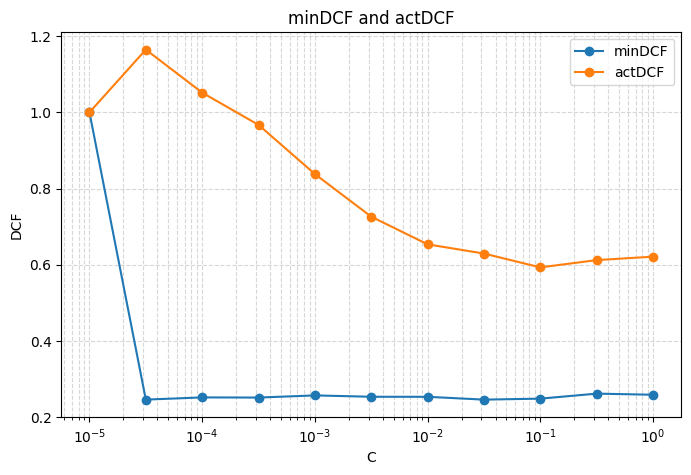

In [6]:
Cs = np.logspace(-5, 0, 11)
d=2
c=1
xi=0

best_scores = None
best_accuracy = -1
DCFs = []

for C in Cs:
    alpha_star = train_polynomial_kernel_SVM(D_training, L_training, C, c, d, xi)
    S = polynomial_kernel_SVM_scores(D_training, L_training, D_eval, alpha_star, c, d, xi)
    preds, accuracy = eval_SVM(S, L_eval)
    if(accuracy > best_accuracy): best_scores = S
    minDFC = compute_min_dcf(S, L_eval, pi_target, 1, 1)
    actDCF = compute_act_dcf(preds, L_eval, pi_target, 1, 1)
    DCFs.append((minDFC, actDCF))

minDCFs = [d[0] for d in DCFs]
actDCFs = [d[1] for d in DCFs]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(Cs, minDCFs, label='minDCF', marker='o')
plt.plot(Cs, actDCFs, label='actDCF', marker='o')
plt.xscale('log')  
plt.xlabel('C')
plt.ylabel('DCF')
plt.title('minDCF and actDCF')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# SVM with RBF kernel

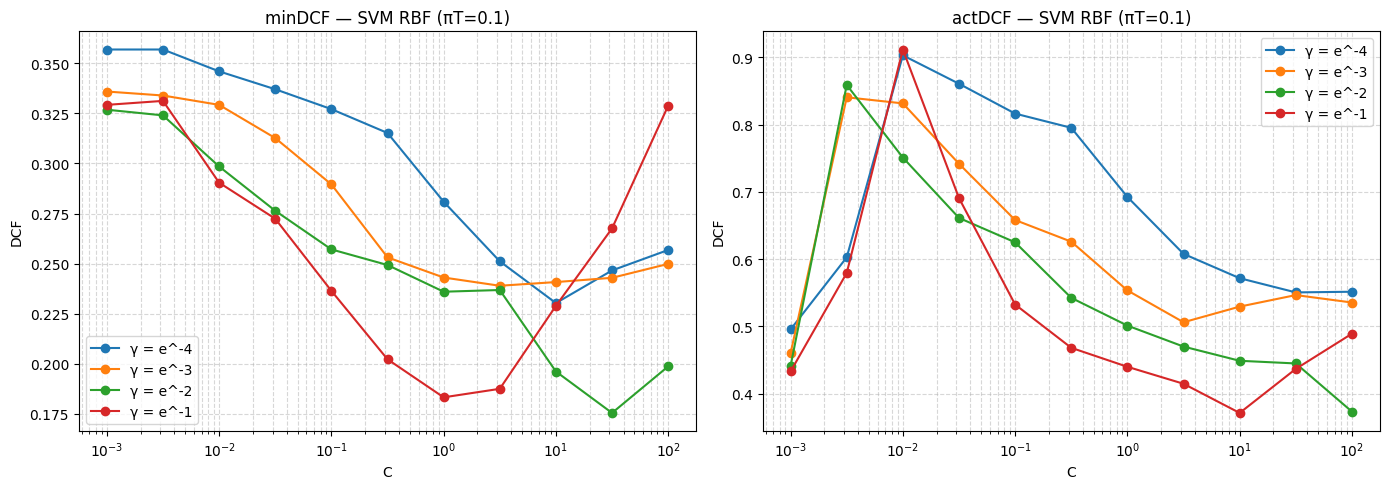

In [7]:
Cs = np.logspace(-3, 2, 11)
gammas = [np.exp(i) for i in range(-4, 0)]

d=2
c=1
xi=1
DCFss = []

for gamma in gammas:
    best_scores = None
    best_accuracy = -1
    
    DCFs = []

    for C in Cs:
        alpha_star = train_rbf_kernel_SVM(D_training, L_training, gamma, C, xi)
        S = rbf_kernel_SVM_scores(D_training, L_training, D_eval, alpha_star, gamma, xi)
        preds, accuracy = eval_SVM(S, L_eval)
        if(accuracy > best_accuracy): best_scores = S
        minDFC = compute_min_dcf(S, L_eval, pi_target, 1, 1)
        actDCF = compute_act_dcf(preds, L_eval, pi_target, 1, 1)
        DCFs.append((minDFC, actDCF))
    DCFss.append(DCFs)



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, (gamma, DCFs) in enumerate(zip(gammas, DCFss)):
    minDCFs = [d[0] for d in DCFs]
    actDCFs = [d[1] for d in DCFs]
    label = f'γ = e^{int(round(np.log(gamma)))}'
    ax1.plot(Cs, minDCFs, marker='o', label=label)
    ax2.plot(Cs, actDCFs, marker='o', label=label)

for ax, title in zip([ax1, ax2], ['minDCF', 'actDCF']):
    ax.set_xscale('log')
    ax.set_xlabel('C')
    ax.set_ylabel('DCF')
    ax.set_title(f'{title} — SVM RBF (πT=0.1)')
    ax.legend()
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()